# Remote Sensing in Arid Regions — Final Project
## OPTRAM analysis of Bushland, Texas (2017–2025)

This is the **simple final notebook**.

The workflow is kept deliberately short:
1. load and clean the existing SAVI–STR table,
2. fit annual OPTRAM trapezoids,
3. plot monthly trajectories,
4. process rainfall,
5. calculate the confirmed wet–dry extent,
6. compare extent with rainfall,
7. show representative dry/wet seasonal trapezoids,
8. plot the AOI.

No Sentinel-2 download is repeated here. The notebook uses the files that already exist in the project folder.


## 1. Imports

In [1]:
import calendar
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from scipy.stats import pearsonr

import pyoptram


## 2. Project paths

All paths point to the existing Bushland project folder.


In [2]:
BASE = Path(r"C:\Users\nivba\Desktop\YearB\SemB\Desertification\Arid-project")

AOI_PATH = BASE / "Bushland.gpkg"
VI_STR_PATH = BASE / "output" / "VI_STR_data.csv"

RAIN_PATH = (
    BASE / "SCAN" / "Bushland#1" /
    "SCAN_SCAN_Bushland#1_p_0.000000_0.000000_not-specified_1_1_19961104_20260518.stm"
)

SM_FILES = [
    BASE / "SCAN" / "Bushland#1" /
    "SCAN_SCAN_Bushland#1_sm_0.050800_0.050800_Stevens-Hydraprobe-Analog_3_1_19961104_20260518.stm",

    BASE / "SCAN" / "Bushland#1" /
    "SCAN_SCAN_Bushland#1_sm_0.050800_0.050800_Stevens-Hydraprobe-Analog_4_1_19961104_20260518.stm"
]


## 3. Load and clean the SAVI–STR data

The existing `VI_STR_data.csv` already contains the satellite-derived vegetation-index and STR values.

The column is stored as `NDVI` in the CSV, but the run was performed with **SAVI**, so it is renamed here.  
Two anomalous acquisition dates identified earlier are removed before the OPTRAM fitting.


In [3]:
aoi = gpd.read_file(AOI_PATH)

vi_str = pd.read_csv(VI_STR_PATH)
vi_str = vi_str.rename(columns={"NDVI": "SAVI"})

vi_str["Date"] = pd.to_datetime(
    vi_str["TimestampUTC"],
    format="mixed",
    utc=True
)

vi_str["Year"] = vi_str["Date"].dt.year
vi_str["Month"] = vi_str["Date"].dt.month

vi_str = vi_str[
    vi_str["Year"].between(2017, 2025)
].copy()

bad_dates = ["2017-02-15", "2018-12-27"]

vi_str_clean = vi_str[
    ~vi_str["Date"].dt.strftime("%Y-%m-%d").isin(bad_dates)
].copy()

print(vi_str_clean["Year"].value_counts().sort_index())


Year
2017     55936
2018     80408
2019     90896
2020    129352
2021    130257
2022    132848
2023    111872
2024    143336
2025    115368
Name: count, dtype: int64


## 4. PyOPTRAM settings

The scientific settings are kept the same as in the original analysis:
- SAVI
- Sentinel-2 tile `14SKD`
- maximum cloud cover 12%
- SWIR Band 11
- linear trapezoid fitting


In [4]:
pyoptram.optram_options("only_vi_str", True)
pyoptram.optram_options("veg_index", "SAVI")
pyoptram.optram_options("tileid", "14SKD")
pyoptram.optram_options("max_cloud", 12)
pyoptram.optram_options("SWIR_band", 11)
pyoptram.optram_options("scm_mask", True)
pyoptram.optram_options("overwrite", False)


{'veg_index': 'SAVI',
 'period': 'full',
 'max_cloud': 12,
 'vi_step': 0.005,
 'trapezoid_method': 'linear',
 'SWIR_band': 11,
 'max_tbl_size': 1000000,
 'rm.low.vi': False,
 'rm.hi.str': False,
 'plot_colors': 'no',
 'feature_col': 'ID',
 'edge_points': True,
 'only_vi_str': True,
 'tileid': '14SKD',
 'scm_mask': True,
 'overwrite': False,
 'save_img_list': False,
 'resolution': 10,
 'area_cover': 99.0,
 'porosity': 0.4}

# 5. Annual OPTRAM trapezoids

For each year, PyOPTRAM fits the wet and dry edges in SAVI–STR space.

The coefficients, RMSE values and edge points are saved in `annual_trapezoids`.



Year: 2017


,edge,method,slope,intercept
0,wet,linear,1.868532,0.793207
1,dry,linear,1.521223,0.133743


,RMSE wet,RMSE dry
0,0.144577,0.054217


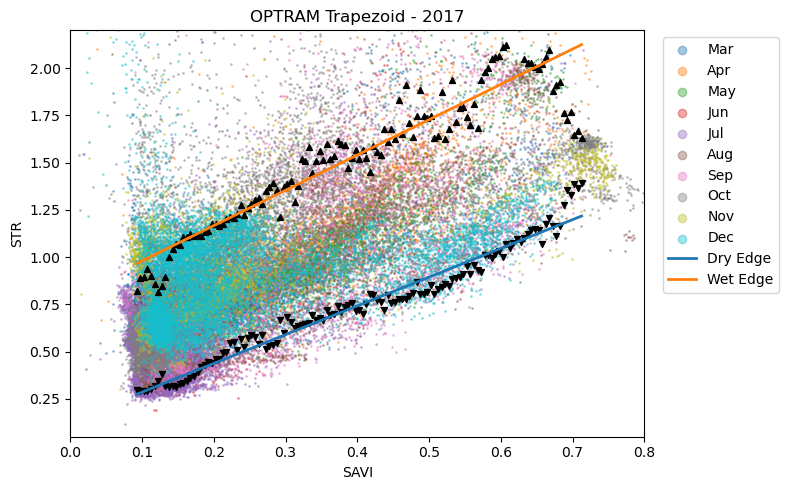


Year: 2018


,edge,method,slope,intercept
0,wet,linear,1.620903,0.637373
1,dry,linear,1.620923,0.060817


,RMSE wet,RMSE dry
0,0.114944,0.048386


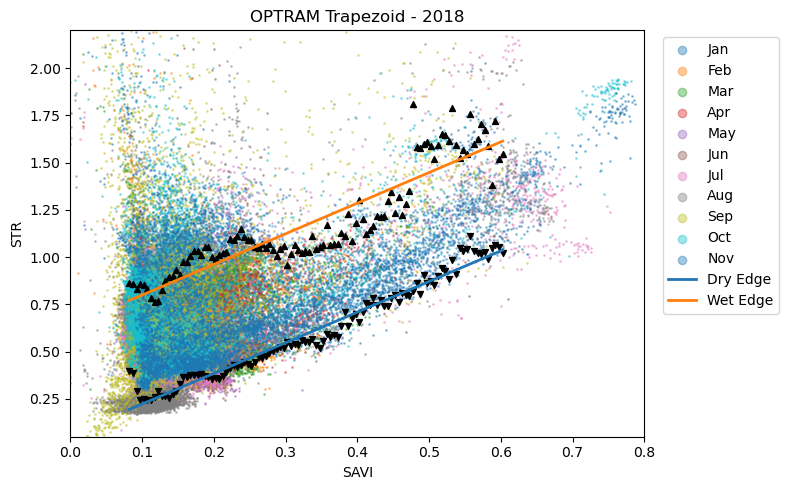


Year: 2019


,edge,method,slope,intercept
0,wet,linear,2.943992,0.750695
1,dry,linear,1.499916,0.171169


,RMSE wet,RMSE dry
0,0.190866,0.049878


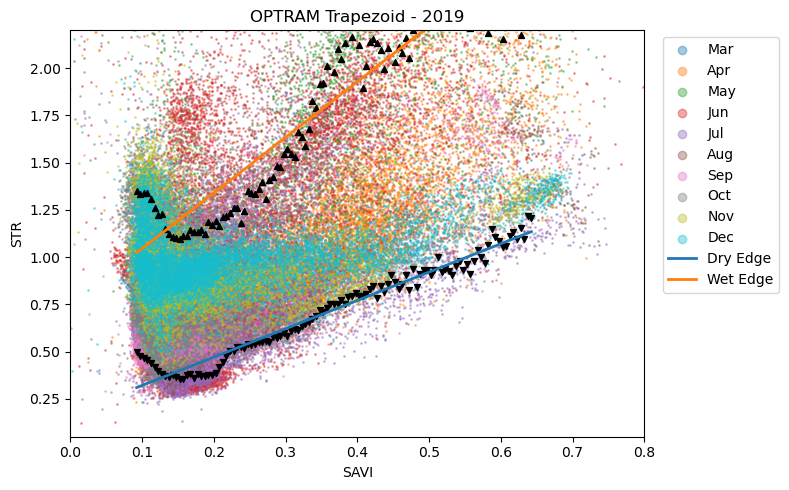


Year: 2020


,edge,method,slope,intercept
0,wet,linear,2.179353,0.659335
1,dry,linear,1.728205,0.143298


,RMSE wet,RMSE dry
0,0.166385,0.04265


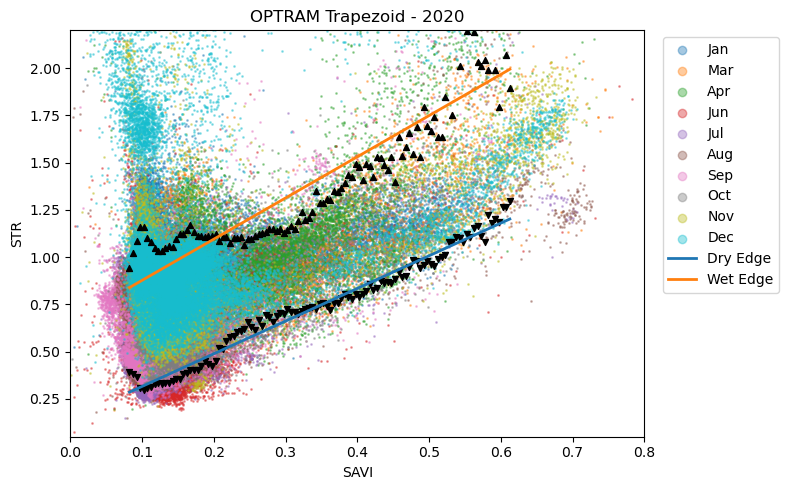


Year: 2021


,edge,method,slope,intercept
0,wet,linear,1.737441,0.601147
1,dry,linear,1.077153,0.219909


,RMSE wet,RMSE dry
0,0.11923,0.031581


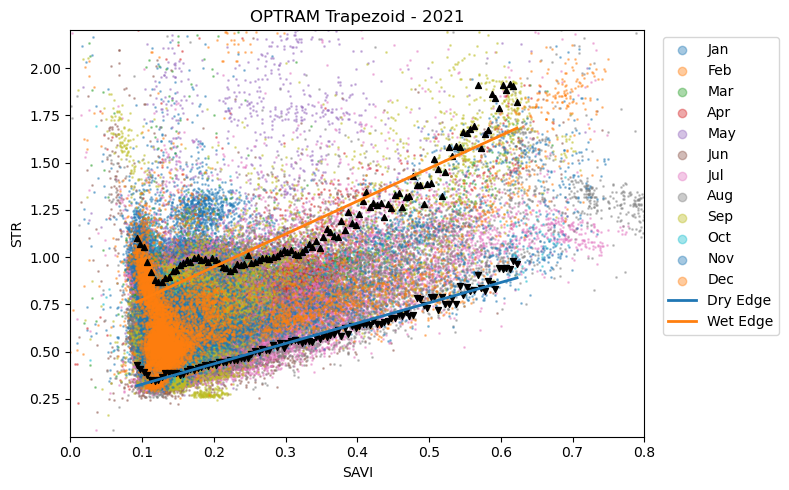


Year: 2022


,edge,method,slope,intercept
0,wet,linear,2.417053,0.433727
1,dry,linear,1.459504,0.086062


,RMSE wet,RMSE dry
0,0.12772,0.034431


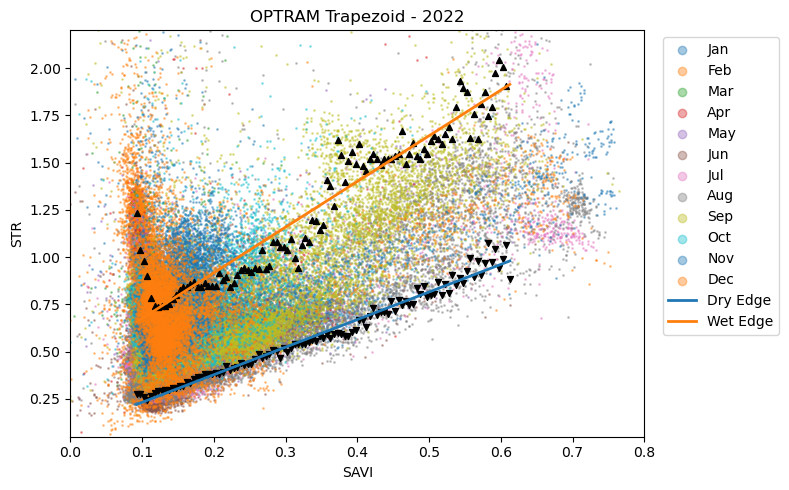


Year: 2023


,edge,method,slope,intercept
0,wet,linear,1.159432,1.026383
1,dry,linear,1.078823,0.215593


,RMSE wet,RMSE dry
0,0.183673,0.0423


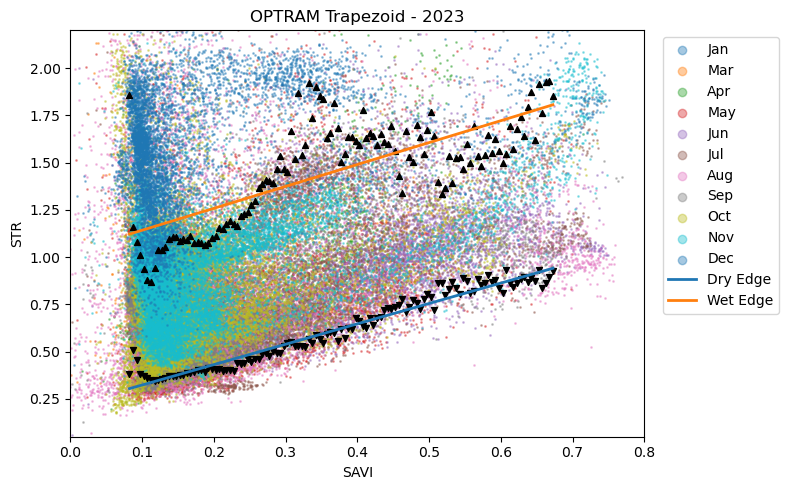


Year: 2024


,edge,method,slope,intercept
0,wet,linear,1.437957,0.858772
1,dry,linear,1.472749,0.146338


,RMSE wet,RMSE dry
0,0.106925,0.064157


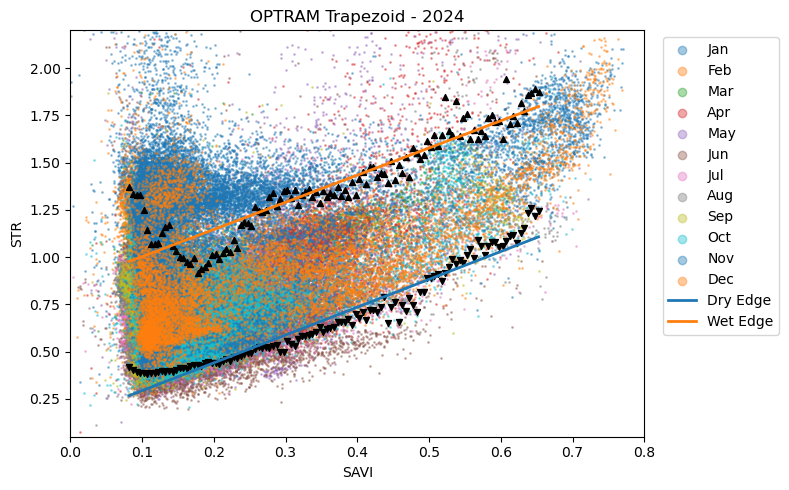


Year: 2025


,edge,method,slope,intercept
0,wet,linear,2.346547,0.795107
1,dry,linear,1.196538,0.274115


,RMSE wet,RMSE dry
0,0.251053,0.052834


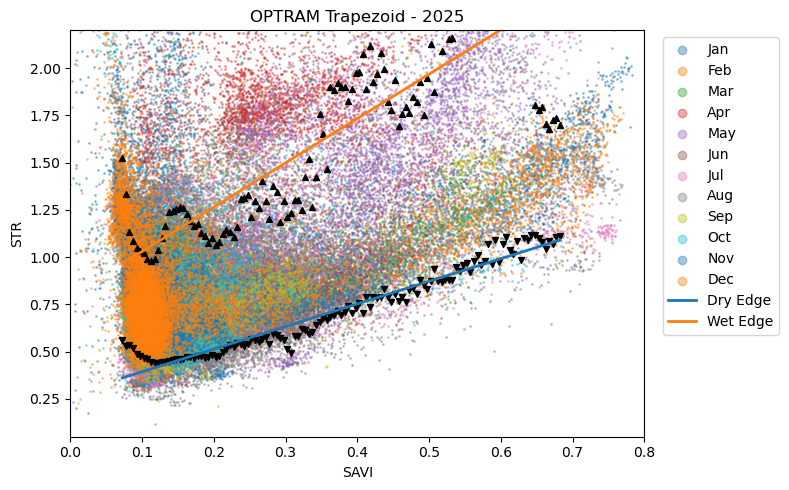

In [46]:
annual_trapezoids = {}

month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}

for year in range(2017, 2026):

    year_data = vi_str_clean[
        vi_str_clean["Year"] == year
    ].copy()

    rmse, coefficients, edges = pyoptram.optram_wetdry_coefficients(
        year_data,
        vi_col="SAVI",
        str_col="STR",
        return_outputs=True)

    annual_trapezoids[year] = {
        "rmse": rmse,
        "coefficients": coefficients,
        "edges": edges}

    print(f"\nYear: {year}")
    display(coefficients)
    display(rmse)

    fig, ax = plt.subplots(figsize=(8, 5))

    # Pixel observations by month
    for month in range(1, 13):

        data = year_data[year_data["Month"] == month]

        if len(data) > 0:
            ax.scatter(
                data["SAVI"],
                data["STR"],
                s=1,
                alpha=0.4,
                label=month_names[month])

    # Dry and Wet edges
    ax.plot(
        edges["VI"],
        edges["STR_dry_fit"],
        linewidth=2,
        label="Dry Edge")

    ax.plot(
        edges["VI"],
        edges["STR_wet_fit"],
        linewidth=2,
        label="Wet Edge")

    # Edge points - visible but not in legend
    ax.scatter(
        edges["VI"],
        edges["STR_dry"],
        color="black",
        marker="v",
        s=18,
        label="_nolegend_")

    ax.scatter(
        edges["VI"],
        edges["STR_wet"],
        color="black",
        marker="^",
        s=18,
        label="_nolegend_")

    ax.set_xlim(0, 0.8)
    ax.set_ylim(0.05, 2.2)

    ax.set_xlabel("SAVI")
    ax.set_ylabel("STR")
    ax.set_title(f"OPTRAM Trapezoid - {year}")

    ax.legend(
        markerscale=6,
        bbox_to_anchor=(1.02, 1),
        loc="upper left")

    plt.tight_layout()
    plt.show()

### Coefficient summary

In [6]:
coeff_table = []

for year in range(2017, 2026):

    coeffs = annual_trapezoids[year]["coefficients"]
    rmse = annual_trapezoids[year]["rmse"]

    wet = coeffs[coeffs["edge"] == "wet"].iloc[0]
    dry = coeffs[coeffs["edge"] == "dry"].iloc[0]

    coeff_table.append({
        "Year": year,
        "Wet_intercept": wet["intercept"],
        "Wet_slope": wet["slope"],
        "Dry_intercept": dry["intercept"],
        "Dry_slope": dry["slope"],
        "RMSE_wet": rmse["RMSE wet"].iloc[0],
        "RMSE_dry": rmse["RMSE dry"].iloc[0]
    })

coeff_table = pd.DataFrame(coeff_table)

display(coeff_table.round(4))


,Year,Wet_intercept,Wet_slope,Dry_intercept,Dry_slope,RMSE_wet,RMSE_dry
0,2017,0.7932,1.8685,0.1337,1.5212,0.1446,0.0542
1,2018,0.6374,1.6209,0.0608,1.6209,0.1149,0.0484
2,2019,0.7507,2.9440,0.1712,1.4999,0.1909,0.0499
3,2020,0.6593,2.1794,0.1433,1.7282,0.1664,0.0427
4,2021,0.6011,1.7374,0.2199,1.0772,0.1192,0.0316
5,2022,0.4337,2.4171,0.0861,1.4595,0.1277,0.0344
6,2023,1.0264,1.1594,0.2156,1.0788,0.1837,0.0423
7,2024,0.8588,1.4380,0.1463,1.4727,0.1069,0.0642
8,2025,0.7951,2.3465,0.2741,1.1965,0.2511,0.0528


# 6. Monthly SAVI–STR trajectories

Each small point is a pixel observation.  
Each large point is the **monthly centroid**: mean SAVI and mean STR for that month.

The black line connects the monthly centroids in chronological order.


In [7]:
year_month = (
    vi_str_clean
    .groupby(["Year", "Month"], as_index=False)[["SAVI", "STR"]]
    .mean()
)


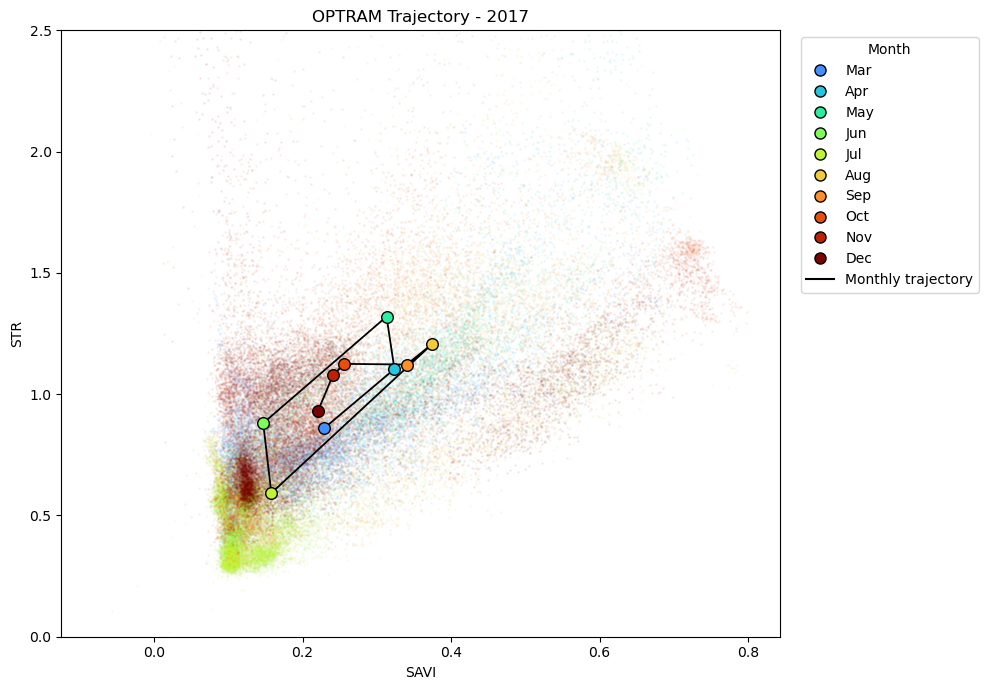

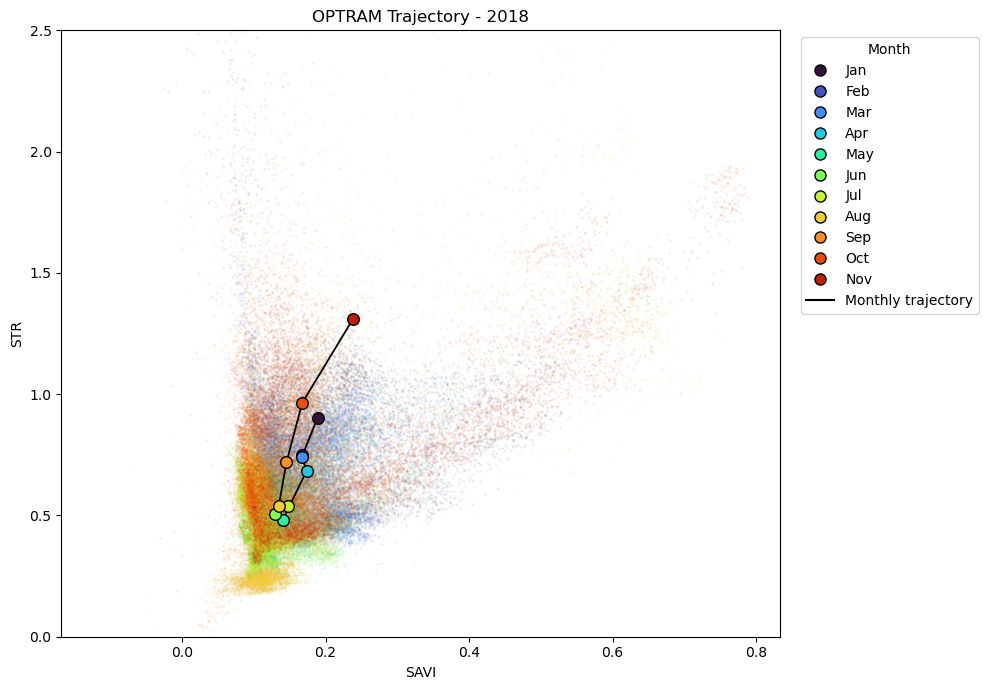

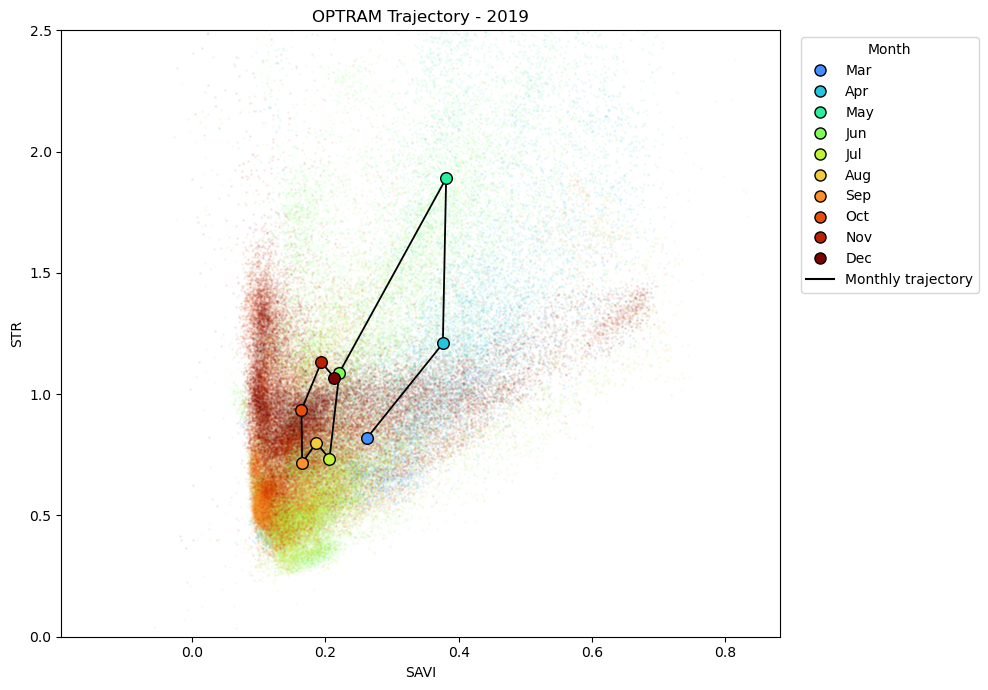

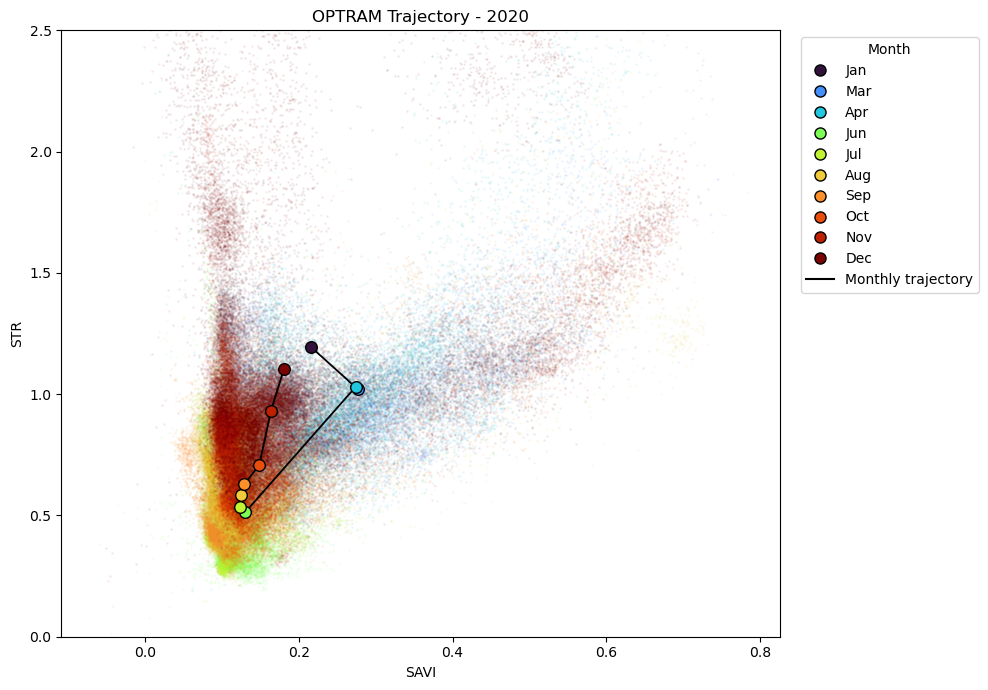

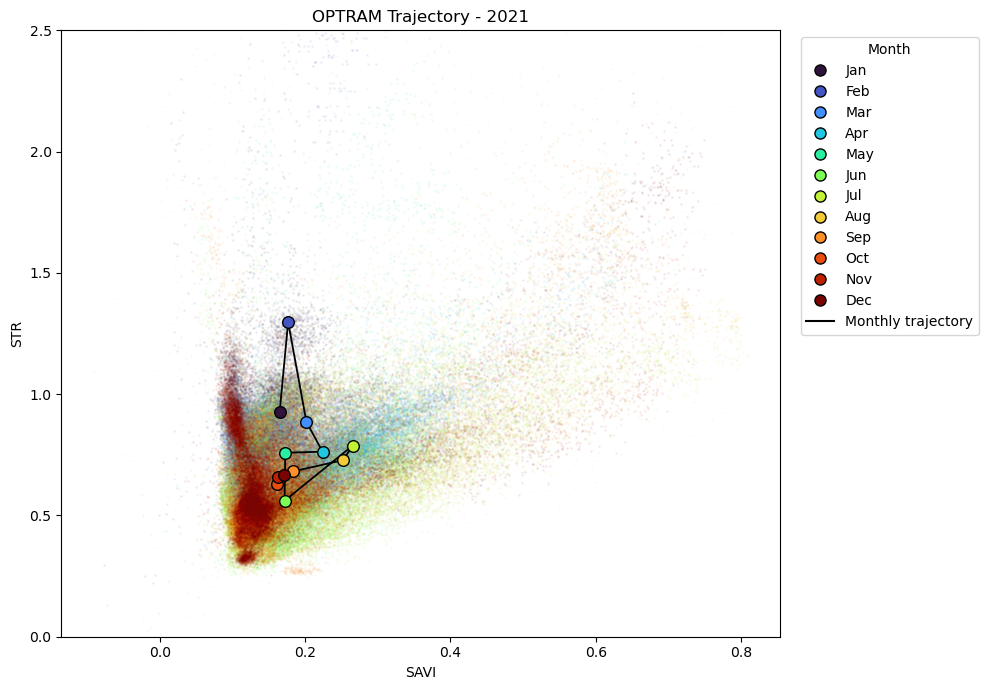

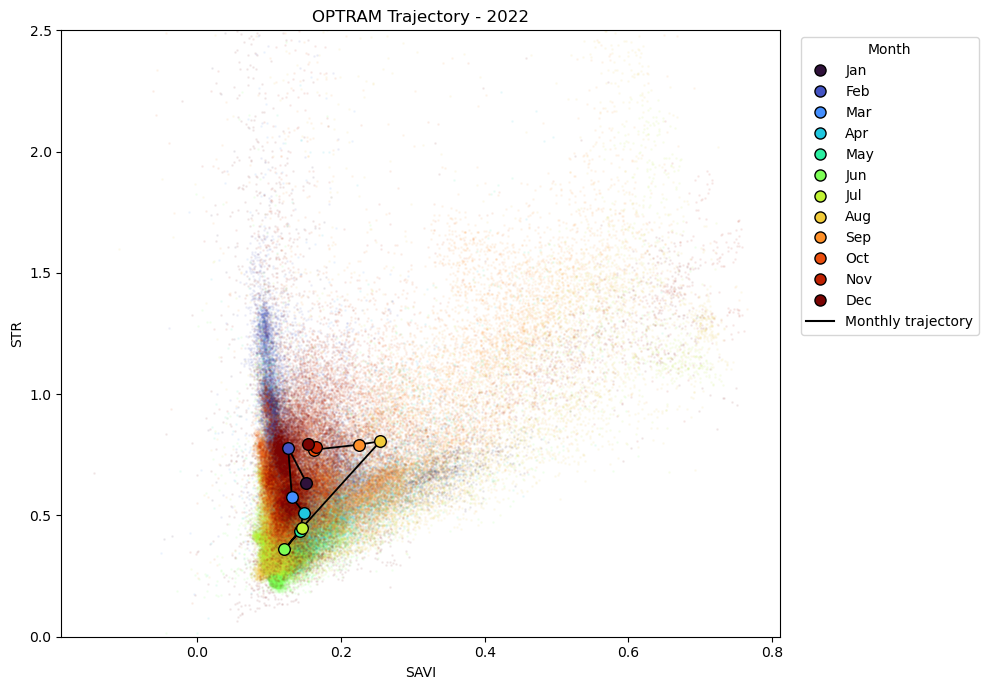

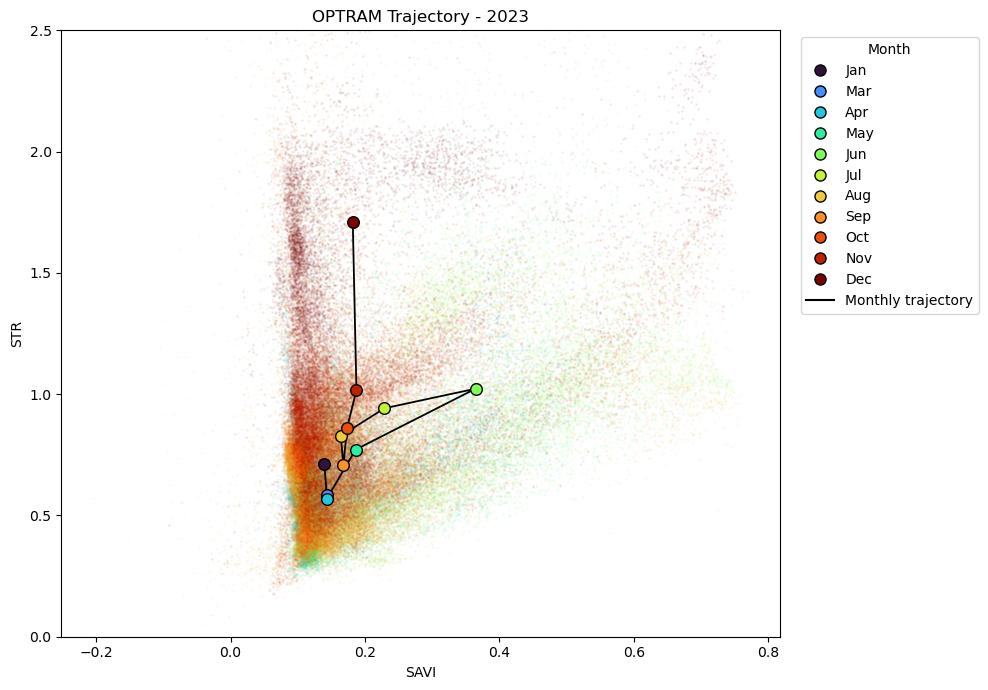

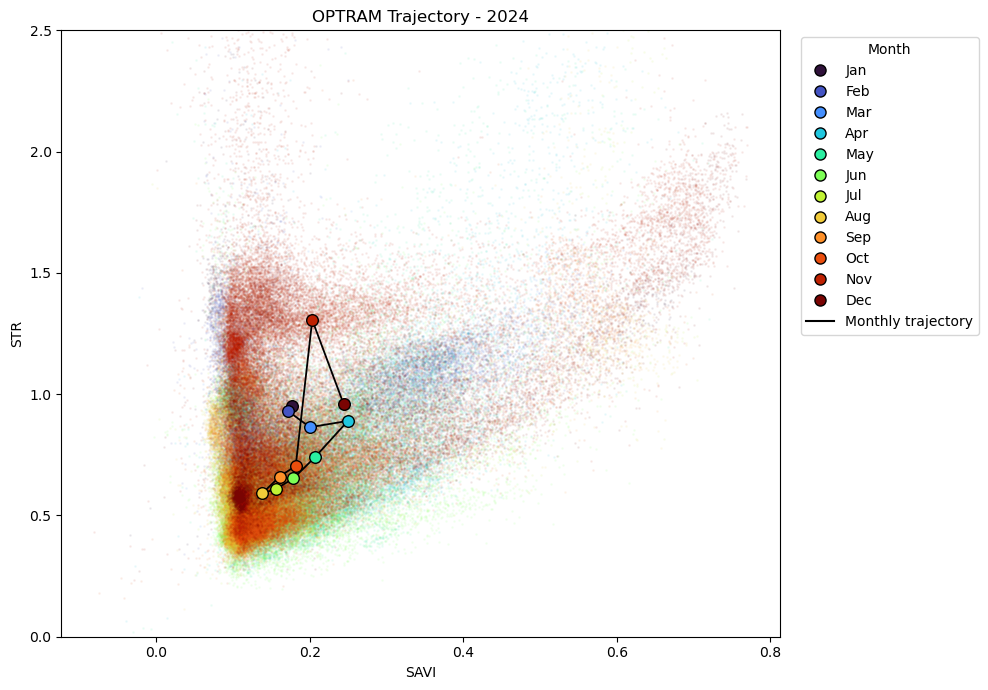

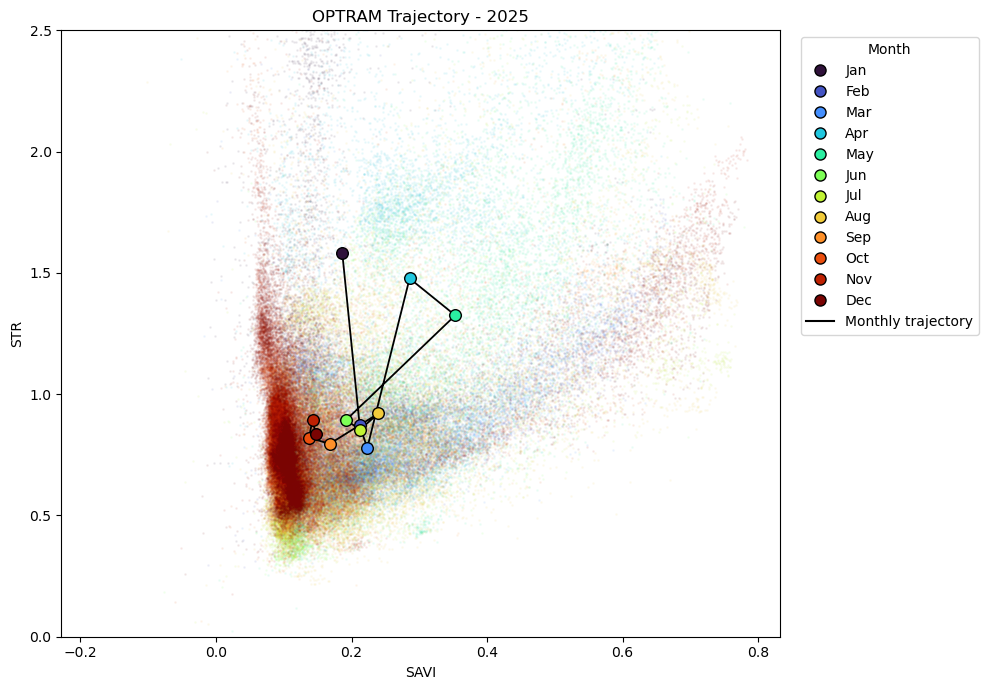

In [8]:
def plot_trajectory(df, year):
    """Plot the monthly SAVI-STR trajectory for a selected year."""

    dates = pd.to_datetime(df["TimestampUTC"], format="mixed", utc=True)
    df = df[dates.dt.year == year]

    monthly = (
        df.groupby("Month", as_index=False)[["SAVI", "STR"]]
        .mean()
        .sort_values("Month")
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    cmap = plt.get_cmap("turbo", 12)

    for _, row in monthly.iterrows():
        month = int(row["Month"])
        color = cmap(month - 1)

        data = df[df["Month"] == month]

        # Pixels
        ax.scatter(
            data["SAVI"],
            data["STR"],
            color=color,
            s=1,
            alpha=0.06
        )

        # Monthly mean
        ax.scatter(
            row["SAVI"],
            row["STR"],
            color=color,
            edgecolor="black",
            s=70,
            zorder=5
        )

    # Trajectory
    ax.plot(
        monthly["SAVI"],
        monthly["STR"],
        color="black",
        linewidth=1.3
    )

    # Legend
    legend_items = []

    for month in monthly["Month"]:
        month = int(month)

        legend_items.append(
            Line2D(
                [0], [0],
                marker="o",
                linestyle="none",
                markerfacecolor=cmap(month - 1),
                markeredgecolor="black",
                markersize=8,
                label=calendar.month_abbr[month]
            )
        )

    legend_items.append(
        Line2D(
            [0], [0],
            color="black",
            label="Monthly trajectory"
        )
    )

    ax.legend(
        handles=legend_items,
        title="Month",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    ax.set_xlabel("SAVI")
    ax.set_ylabel("STR")
    ax.set_ylim(0, 2.5)
    ax.set_title(f"OPTRAM Trajectory - {year}")

    plt.tight_layout()
    plt.show()


for year in range(2017, 2026):
    plot_trajectory(vi_str_clean, year)


# 7. Rainfall

Hourly rainfall from Bushland #1 SCAN is converted to monthly totals and annual totals.


In [9]:
rain = pd.read_csv(
    RAIN_PATH,
    sep=r"\s+",
    skiprows=1,
    header=None,
    names=["Date", "Time", "Rainfall", "Quality", "Flag"]
)

rain["DateTime"] = pd.to_datetime(
    rain["Date"] + " " + rain["Time"],
    format="%Y/%m/%d %H:%M"
)

rain["Rainfall"] = pd.to_numeric(
    rain["Rainfall"],
    errors="coerce"
)

rain = rain[rain["Rainfall"] >= 0].copy()

rain["Year"] = rain["DateTime"].dt.year
rain["Month"] = rain["DateTime"].dt.month

rain = rain[
    rain["Year"].between(2017, 2025)
].copy()

monthly_rain = (
    rain
    .groupby(["Year", "Month"], as_index=False)["Rainfall"]
    .sum()
)

annual_rainfall = (
    monthly_rain
    .groupby("Year", as_index=False)["Rainfall"]
    .sum()
)

display(annual_rainfall)


,Year,Rainfall
0,2017,462.788
1,2018,349.504
2,2019,481.838
3,2020,171.704
4,2021,275.082
5,2022,290.576
6,2023,514.604
7,2024,431.800
8,2025,475.742


### Mean monthly rainfall

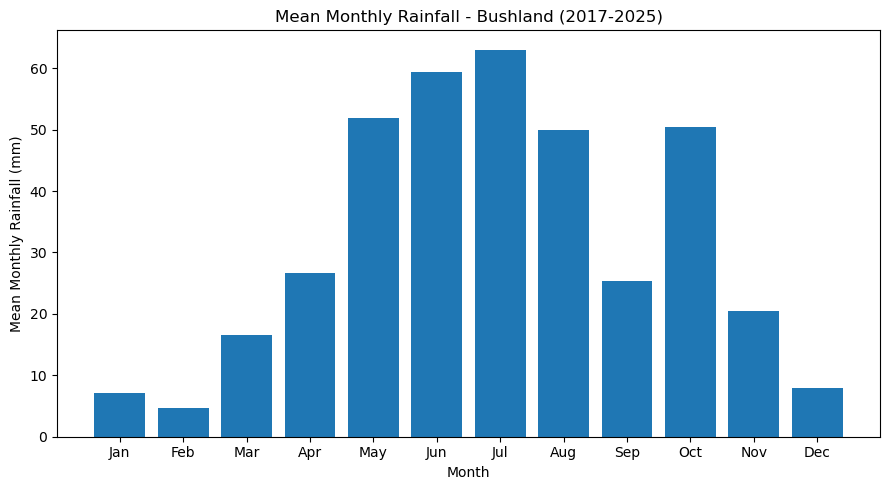

In [10]:
mean_monthly_rain = (
    monthly_rain
    .groupby("Month", as_index=False)["Rainfall"]
    .mean()
)

mean_monthly_rain["Month_name"] = mean_monthly_rain["Month"].apply(
    lambda m: calendar.month_abbr[m]
)

plt.figure(figsize=(9, 5))
plt.bar(
    mean_monthly_rain["Month_name"],
    mean_monthly_rain["Rainfall"]
)
plt.xlabel("Month")
plt.ylabel("Mean Monthly Rainfall (mm)")
plt.title("Mean Monthly Rainfall - Bushland (2017-2025)")
plt.tight_layout()
plt.show()


# 8. Wet–dry extent — final method

This is the method clarified by the instructor.

For each year:
- **Dry endpoint** = monthly centroid with the **minimum mean STR**
- **Wet endpoint** = monthly centroid with the **maximum mean STR**

The line between these two points is the annual wet–dry extent.

The endpoint selection uses only the SAVI–STR trajectory.  
Rainfall is compared with the resulting extent metrics afterward.


In [27]:
extent_rows = []

for year in range(2017, 2026):

    data = year_month[
        year_month["Year"] == year
    ].copy()

    dry = data.loc[data["STR"].idxmin()]
    wet = data.loc[data["STR"].idxmax()]

    delta_savi = wet["SAVI"] - dry["SAVI"]
    delta_str = wet["STR"] - dry["STR"]

    length = np.sqrt(delta_savi**2 + delta_str**2)

    angle = np.degrees(np.arctan(delta_str/delta_savi))

    extent_rows.append({
        "Year": year,
        "Dry_Month": int(dry["Month"]),
        "Wet_Month": int(wet["Month"]),
        "Dry_SAVI": dry["SAVI"],
        "Dry_STR": dry["STR"],
        "Wet_SAVI": wet["SAVI"],
        "Wet_STR": wet["STR"],
        "Delta_SAVI": delta_savi,
        "Delta_STR": delta_str,
        "Extent_Length": length,
        "Extent_Angle": angle
    })

extent_table = pd.DataFrame(extent_rows)

display(extent_table.round(3))


,Year,Dry_Month,Wet_Month,Dry_SAVI,Dry_STR,Wet_SAVI,Wet_STR,Delta_SAVI,Delta_STR,Extent_Length,Extent_Angle
0,2017,7,5,0.158,0.592,0.313,1.320,0.155,0.728,0.744,77.959
1,2018,5,11,0.140,0.480,0.238,1.309,0.098,0.829,0.834,83.261
2,2019,9,5,0.165,0.717,0.381,1.890,0.216,1.173,1.193,79.558
3,2020,6,1,0.130,0.514,0.216,1.194,0.086,0.680,0.685,82.821
4,2021,6,2,0.172,0.561,0.177,1.297,0.005,0.736,0.736,89.616
5,2022,6,8,0.121,0.360,0.255,0.806,0.133,0.446,0.465,73.320
6,2023,4,12,0.143,0.568,0.182,1.710,0.039,1.143,1.143,88.052
7,2024,8,11,0.138,0.591,0.203,1.306,0.065,0.715,0.718,84.791
8,2025,3,1,0.223,0.778,0.186,1.580,-0.037,0.802,0.803,-87.374


### Clean multiyear extent plot

To avoid overlapping labels:
- open circle = dry endpoint
- triangle = wet endpoint
- the legend gives the year and the dry → wet months


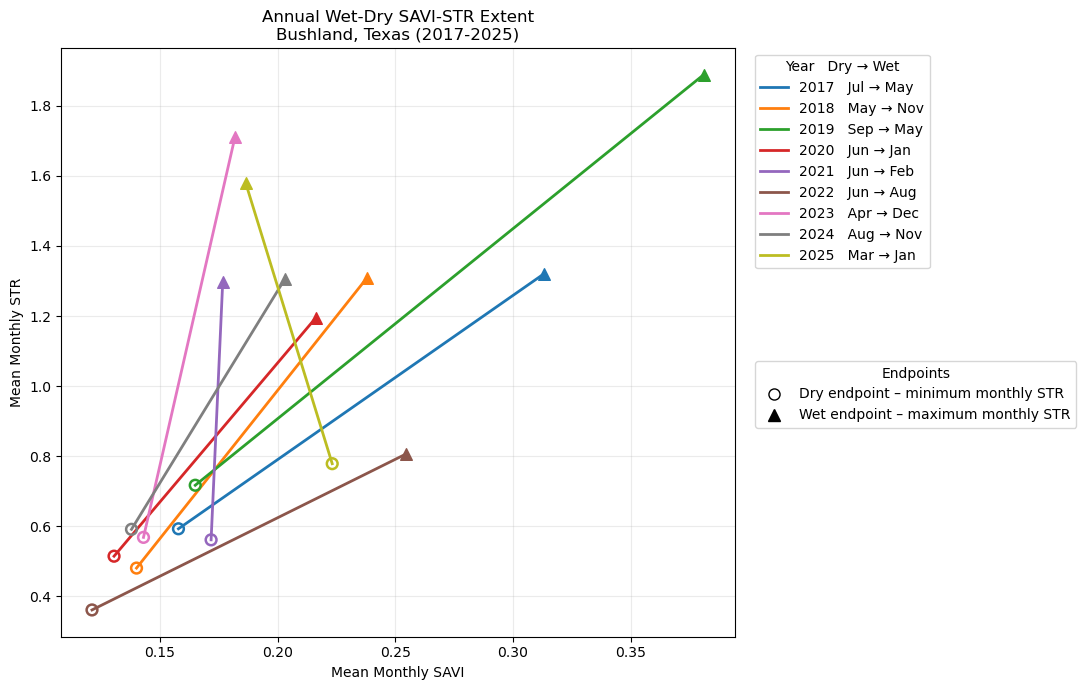

In [44]:
fig, ax = plt.subplots(figsize=(11, 7))

year_handles = []

for _, row in extent_table.iterrows():

    dry_name = calendar.month_abbr[int(row["Dry_Month"])]
    wet_name = calendar.month_abbr[int(row["Wet_Month"])]

    line, = ax.plot(
        [row["Dry_SAVI"], row["Wet_SAVI"]],
        [row["Dry_STR"], row["Wet_STR"]],
        linewidth=2,
        label=f'{int(row["Year"])}   {dry_name} → {wet_name}'
    )

    color = line.get_color()

    # Dry endpoint
    ax.scatter(
        row["Dry_SAVI"],
        row["Dry_STR"],
        marker="o",
        s=60,
        facecolors="none",
        edgecolors=color,
        linewidths=1.8,
        zorder=5
    )

    # Wet endpoint
    ax.scatter(
        row["Wet_SAVI"],
        row["Wet_STR"],
        marker="^",
        s=70,
        color=color,
        zorder=5
    )

    year_handles.append(line)


# Marker legend
marker_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor="none",
        markeredgecolor="black",
        markersize=8,
        label="Dry endpoint – minimum monthly STR"
    ),
    Line2D(
        [0], [0],
        marker="^",
        linestyle="none",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=8,
        label="Wet endpoint – maximum monthly STR"
    )
]


ax.set_xlabel("Mean Monthly SAVI")
ax.set_ylabel("Mean Monthly STR")

ax.set_title(
    "Annual Wet-Dry SAVI-STR Extent\n"
    "Bushland, Texas (2017-2025)"
)

ax.grid(alpha=0.25)

# Legend for years
legend1 = ax.legend(
    handles=year_handles,
    title="Year   Dry → Wet",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.add_artist(legend1)

# Legend for symbols
ax.legend(
    handles=marker_handles,
    title="Endpoints",
    bbox_to_anchor=(1.02, 0.48),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# 9. Extent versus rainfall

The extent is calculated independently from SAVI–STR.  
Here it is compared with **annual rainfall** using Pearson correlation.


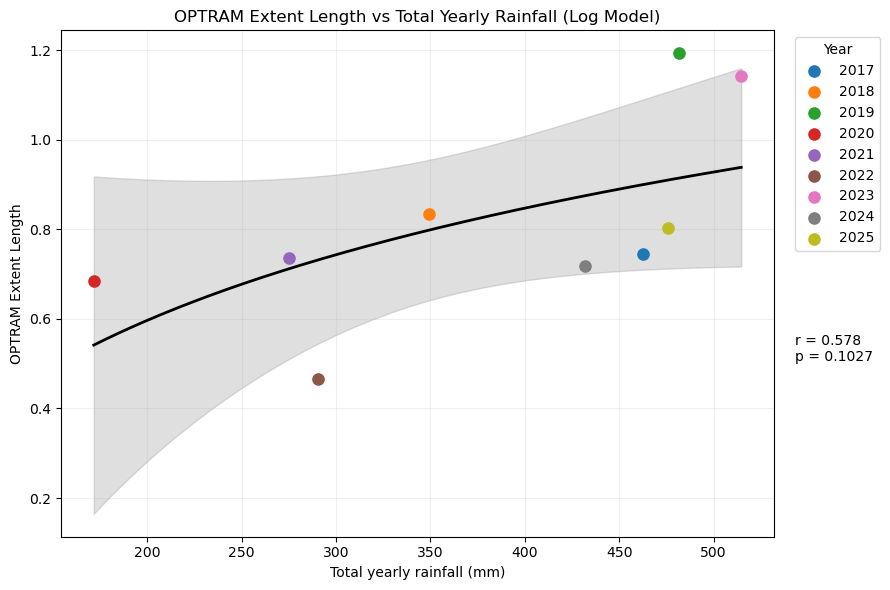

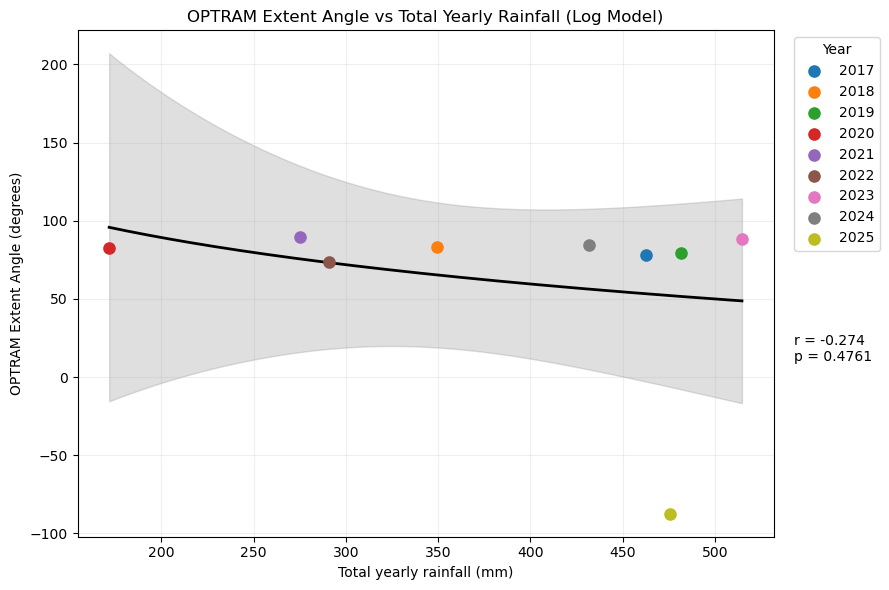

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, t

# Combine extent results with annual rainfall
extent_rain = extent_table.merge(
    annual_rainfall,
    on="Year"
).reset_index(drop=True)

graphs = [
    (
        "Extent_Length",
        "OPTRAM Extent Length",
        "OPTRAM Extent Length vs Total Yearly Rainfall"
    ),
    (
        "Extent_Angle",
        "OPTRAM Extent Angle (degrees)",
        "OPTRAM Extent Angle vs Total Yearly Rainfall"
    )
]

cmap = plt.get_cmap("tab10")

for metric, ylabel, title in graphs:

    x = extent_rain["Rainfall"].to_numpy()
    y = extent_rain[metric].to_numpy()

    # Log transformation
    log_x = np.log(x)

    # Correlation
    r, p = pearsonr(log_x, y)

    # Log regression
    slope, intercept = np.polyfit(log_x, y, 1)

    x_line = np.linspace(x.min(), x.max(), 200)
    log_x_line = np.log(x_line)
    y_line = intercept + slope * log_x_line

    # 95% confidence interval
    y_fit = intercept + slope * log_x
    residuals = y - y_fit

    n = len(x)
    se = np.sqrt(np.sum(residuals**2) / (n - 2))

    x_mean = log_x.mean()
    ssx = np.sum((log_x - x_mean)**2)

    ci = t.ppf(0.975, n - 2) * se * np.sqrt(
        1/n + (log_x_line - x_mean)**2 / ssx
    )

    # Plot
    fig, ax = plt.subplots(figsize=(9, 6))

    for i, row in extent_rain.iterrows():
        ax.scatter(
            row["Rainfall"],
            row[metric],
            s=65,
            color=cmap(i),
            label=str(int(row["Year"])),
            zorder=3
        )

    # Confidence interval
    ax.fill_between(
        x_line,
        y_line - ci,
        y_line + ci,
        color="gray",
        alpha=0.25
    )

    # Regression line
    ax.plot(
        x_line,
        y_line,
        color="black",
        linewidth=2
    )

    ax.set_xlabel("Total yearly rainfall (mm)")
    ax.set_ylabel(ylabel)

    ax.set_title(
        title + " (Log Model)"
    )

    ax.legend(
        title="Year",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    # Statistics
    ax.text(
        1.03,
        0.40,
        f"r = {r:.3f}\n"
        f"p = {p:.4f}\n",
        transform=ax.transAxes,
        fontsize=10,
        va="top"
    )

    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

## 10. Monthly rainfall–STR correlation for each year

This gives a separate monthly rainfall–STR correlation for every year, as an additional temporal comparison.


In [30]:
rain_str = monthly_rain.merge(
    year_month,
    on=["Year", "Month"]
)

rows = []

for year in range(2017, 2026):

    d = rain_str[
        rain_str["Year"] == year
    ].dropna()

    if len(d) >= 3:
        r, p = pearsonr(
            d["Rainfall"],
            d["STR"]
        )

        rows.append({
            "Year": year,
            "n": len(d),
            "Pearson_r": r,
            "p_value": p
        })

yearly_rain_str = pd.DataFrame(rows)

display(yearly_rain_str.round(4))


,Year,n,Pearson_r,p_value
0,2017,10,0.0928,0.7988
1,2018,11,0.1205,0.7242
2,2019,10,0.3797,0.2791
3,2020,10,-0.7171,0.0196
4,2021,12,-0.2278,0.4763
5,2022,12,-0.3384,0.2819
6,2023,11,0.0930,0.7856
7,2024,12,0.3169,0.3156
8,2025,12,0.2947,0.3524


# 11. SCAN soil moisture

The two 5.08 cm SCAN sensor files are combined.

Only observations with `Quality == "G"` are retained.  
Monthly means are kept only when at least 80% of the days in that month contain valid data.


In [31]:
def read_soil_moisture(path):

    df = pd.read_csv(
        path,
        sep=r"\s+",
        skiprows=1,
        header=None,
        names=["Date", "Time", "Soil_Moisture", "Quality", "Flag"]
    )

    df["DateTime"] = pd.to_datetime(
        df["Date"] + " " + df["Time"],
        format="%Y/%m/%d %H:%M"
    )

    df["Soil_Moisture"] = pd.to_numeric(
        df["Soil_Moisture"],
        errors="coerce"
    )

    return df


insitu = pd.concat(
    [read_soil_moisture(path) for path in SM_FILES],
    ignore_index=True
)

insitu = insitu[
    insitu["DateTime"].dt.year.between(2017, 2025)
    & (insitu["Quality"] == "G")
    & insitu["Soil_Moisture"].notna()
].copy()

insitu["Year"] = insitu["DateTime"].dt.year
insitu["Month"] = insitu["DateTime"].dt.month
insitu["Day"] = insitu["DateTime"].dt.date

daily_insitu = (
    insitu
    .groupby(["Year", "Month", "Day"], as_index=False)["Soil_Moisture"]
    .mean()
)

monthly_insitu = (
    daily_insitu
    .groupby(["Year", "Month"], as_index=False)
    .agg(
        Soil_Moisture=("Soil_Moisture", "mean"),
        Days_With_Data=("Day", "nunique")
    )
)

monthly_insitu["Days_In_Month"] = monthly_insitu.apply(
    lambda row: calendar.monthrange(
        int(row["Year"]),
        int(row["Month"])
    )[1],
    axis=1
)

monthly_insitu["Coverage_pct"] = (
    monthly_insitu["Days_With_Data"]
    / monthly_insitu["Days_In_Month"]
    * 100
)

monthly_insitu_good = monthly_insitu[
    monthly_insitu["Coverage_pct"] >= 80
].copy()



### Rainfall versus measured SCAN soil moisture

In [32]:
rain_scan = monthly_rain.merge(
    monthly_insitu_good[
        ["Year", "Month", "Soil_Moisture"]
    ],
    on=["Year", "Month"]
)

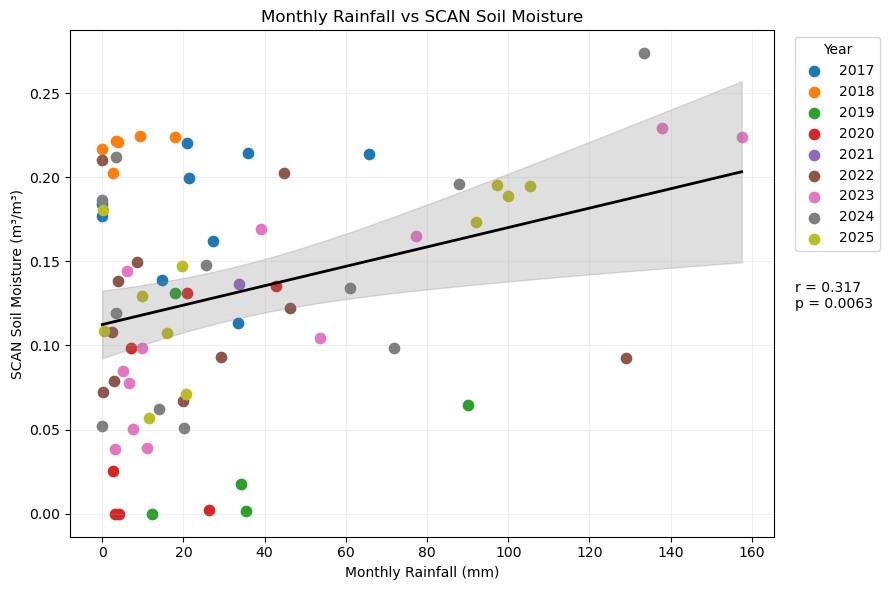

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, t

x = rain_scan["Rainfall"].to_numpy()
y = rain_scan["Soil_Moisture"].to_numpy()

# Correlation
r, p = pearsonr(x, y)

# Linear regression
slope, intercept = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

# 95% confidence interval
y_fit = slope * x + intercept
residuals = y - y_fit

n = len(x)
se = np.sqrt(np.sum(residuals**2) / (n - 2))

x_mean = x.mean()
ssx = np.sum((x - x_mean)**2)

ci = t.ppf(0.975, n - 2) * se * np.sqrt(
    1/n + (x_line - x_mean)**2 / ssx
)

fig, ax = plt.subplots(figsize=(9, 6))

for year, data in rain_scan.groupby("Year"):
    ax.scatter(
        data["Rainfall"],
        data["Soil_Moisture"],
        s=55,
        label=str(year)
    )

# Gray confidence band
ax.fill_between(
    x_line,
    y_line - ci,
    y_line + ci,
    color="gray",
    alpha=0.25
)

# Regression line
ax.plot(
    x_line,
    y_line,
    color="black",
    linewidth=2
)

ax.set_xlabel("Monthly Rainfall (mm)")
ax.set_ylabel("SCAN Soil Moisture (m³/m³)")
ax.set_title("Monthly Rainfall vs SCAN Soil Moisture")

ax.legend(
    title="Year",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.text(
    1.03, 0.42,
    f"r = {r:.3f}\n"
    f"p = {p:.4f}\n",
    transform=ax.transAxes
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# 13. Representative dry and wet seasonal trapezoids

From the complete 3-month rainfall seasons:
- **Driest:** Winter 2018 = Dec 2017 + Jan–Feb 2018
- **Wettest:** Summer 2017 = Jun–Aug 2017

These plots are separate from the annual wet–dry extent analysis.


In [19]:
season_data = monthly_rain.copy()

season_data["Season"] = season_data["Month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
})

# December belongs to the following winter
season_data["SeasonYear"] = season_data["Year"]
season_data.loc[
    season_data["Month"] == 12,
    "SeasonYear"
] += 1

seasonal_rain = (
    season_data
    .groupby(["SeasonYear", "Season"], as_index=False)
    .agg(
        Rainfall=("Rainfall", "sum"),
        Months=("Month", "nunique")
    )
)

# Keep only complete 3-month seasons
seasonal_rain = seasonal_rain[
    (seasonal_rain["Months"] == 3) &
    (seasonal_rain["SeasonYear"].between(2017, 2025))
].copy()

display(
    seasonal_rain
    .sort_values("Rainfall")
    .reset_index(drop=True)
)

,SeasonYear,Season,Rainfall,Months
0,2018,Winter,2.540,3
1,2025,Winter,3.302,3
2,2022,Winter,3.810,3
3,2021,Winter,6.096,3
4,2023,Winter,14.986,3
5,2018,Spring,16.510,3
6,2019,Winter,19.812,3
7,2020,Winter,25.400,3
8,2022,Spring,28.702,3
9,2020,Spring,36.068,3


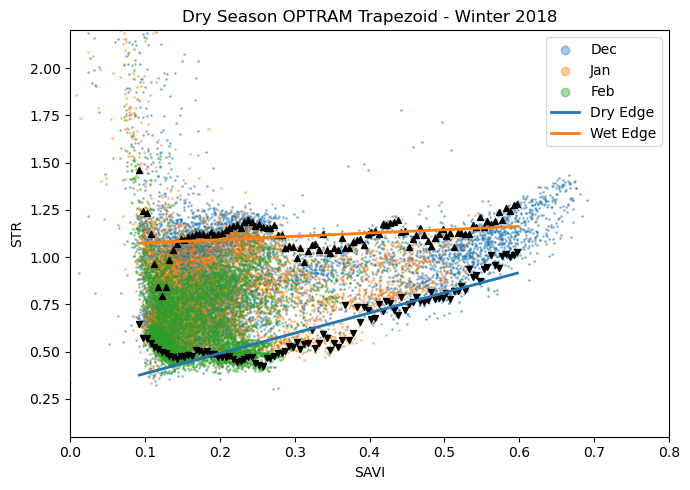

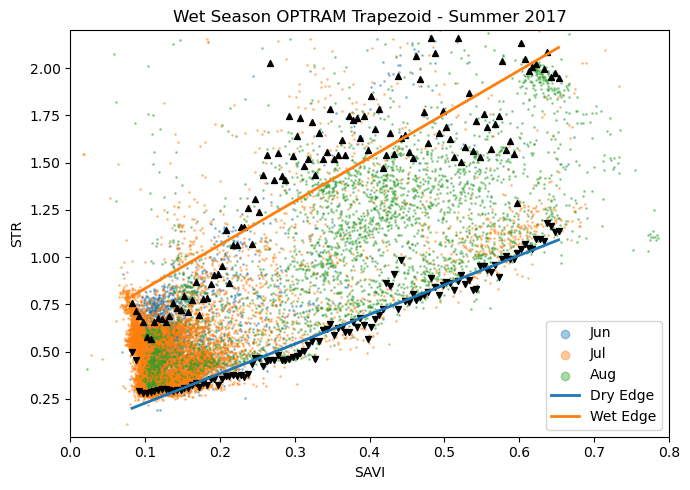

In [43]:
dry_season = vi_str_clean[((vi_str_clean["Year"] == 2017) & (vi_str_clean["Month"] == 12)) | ((vi_str_clean["Year"] == 2018) & (vi_str_clean["Month"].isin([1, 2])))].copy()
wet_season = vi_str_clean[(vi_str_clean["Year"] == 2017) & (vi_str_clean["Month"].isin([6, 7, 8]))].copy()

# Dry season
rmse_dry, coeff_dry, edges_dry = pyoptram.optram_wetdry_coefficients(dry_season, vi_col="SAVI", str_col="STR", return_outputs=True)

fig, ax = plt.subplots(figsize=(7, 5))

for month, label in [(12, "Dec"), (1, "Jan"), (2, "Feb")]:
    data = dry_season[dry_season["Month"] == month]
    ax.scatter(data["SAVI"], data["STR"], s=1, alpha=0.4, label=label)

ax.plot(edges_dry["VI"], edges_dry["STR_dry_fit"], linewidth=2, label="Dry Edge")
ax.plot(edges_dry["VI"], edges_dry["STR_wet_fit"], linewidth=2, label="Wet Edge")
ax.scatter(edges_dry["VI"], edges_dry["STR_dry"], color="black", marker="v", s=18, label="_nolegend_")
ax.scatter(edges_dry["VI"], edges_dry["STR_wet"], color="black", marker="^", s=18, label="_nolegend_")

ax.set_xlim(0, 0.8)
ax.set_ylim(0.05, 2.2)
ax.set_xlabel("SAVI")
ax.set_ylabel("STR")
ax.set_title("Dry Season OPTRAM Trapezoid - Winter 2018")
legend = ax.legend(markerscale=6)
plt.tight_layout()
plt.show()


# Wet season
rmse_wet, coeff_wet, edges_wet = pyoptram.optram_wetdry_coefficients(wet_season, vi_col="SAVI", str_col="STR", return_outputs=True)

fig, ax = plt.subplots(figsize=(7, 5))

for month, label in [(6, "Jun"), (7, "Jul"), (8, "Aug")]:
    data = wet_season[wet_season["Month"] == month]
    ax.scatter(data["SAVI"], data["STR"], s=1, alpha=0.4, label=label)

ax.plot(edges_wet["VI"], edges_wet["STR_dry_fit"], linewidth=2, label="Dry Edge")
ax.plot(edges_wet["VI"], edges_wet["STR_wet_fit"], linewidth=2, label="Wet Edge")
ax.scatter(edges_wet["VI"], edges_wet["STR_dry"], color="black", marker="v", s=18, label="_nolegend_")
ax.scatter(edges_wet["VI"], edges_wet["STR_wet"], color="black", marker="^", s=18, label="_nolegend_")

ax.set_xlim(0, 0.8)
ax.set_ylim(0.05, 2.2)
ax.set_xlabel("SAVI")
ax.set_ylabel("STR")
ax.set_title("Wet Season OPTRAM Trapezoid - Summer 2017")
legend = ax.legend(markerscale=6)
plt.tight_layout()
plt.show()

# 14. Simple AOI map

A minimal map of the study-area polygon and the Bushland #1 SCAN station.  
No extra basemap package is required.


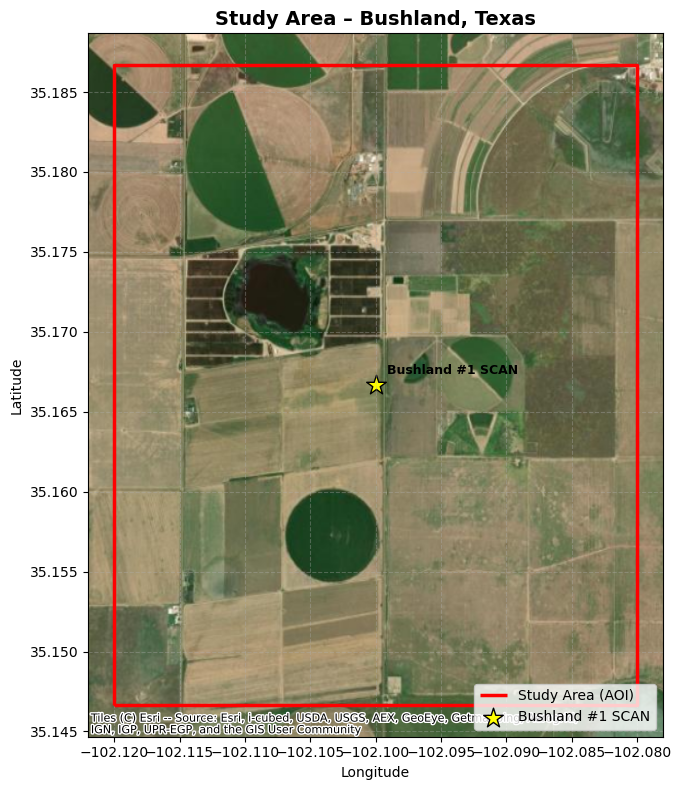

In [21]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point

# AOI in geographic coordinates
aoi_map = aoi.to_crs("EPSG:4326")

# Bushland #1 SCAN station
station = gpd.GeoDataFrame(
    {"Name": ["Bushland #1 SCAN"]},
    geometry=[Point(-102.10000, 35.16667)],
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(9, 8))

# AOI boundary
aoi_map.boundary.plot(
    ax=ax,
    color="red",
    linewidth=2.5,
    label="Study Area (AOI)"
)

# Map extent
minx, miny, maxx, maxy = aoi_map.total_bounds

dx = (maxx - minx) * 0.05
dy = (maxy - miny) * 0.05

ax.set_xlim(minx - dx, maxx + dx)
ax.set_ylim(miny - dy, maxy + dy)

# Satellite imagery
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery,
    crs=aoi_map.crs
)

# SCAN station
station.plot(
    ax=ax,
    marker="*",
    markersize=220,
    color="yellow",
    edgecolor="black",
    linewidth=1,
    label="Bushland #1 SCAN"
)

# Station label
ax.annotate(
    "Bushland #1 SCAN",
    xy=(-102.10000, 35.16667),
    xytext=(8, 8),
    textcoords="offset points",
    fontweight="bold",
    fontsize=9
)

ax.set_title(
    "Study Area – Bushland, Texas",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.legend(loc="lower right")

ax.grid(
    linestyle="--",
    alpha=0.35
)

plt.tight_layout()
plt.show()